<a href="https://colab.research.google.com/github/MudasirH-coder/Mudasir-demo/blob/main/Engro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [10]:
df = pd.read_csv('/content/engro-fertilizers-limited-pakistan-stock-exchange-2014-2022.csv')
df.head(10)

,Date,Open,High,Low,Close,Volume
0,1/17/2014,0.00,29.66,29.66,29.66,0
1,1/20/2014,31.14,31.14,31.14,31.14,1000
2,1/21/2014,32.69,32.69,32.69,32.69,2500
3,1/22/2014,34.32,34.32,34.32,34.32,2000
4,1/23/2014,36.03,36.03,36.03,36.03,12500
5,1/24/2014,37.83,37.83,37.83,37.83,3500
6,1/27/2014,39.72,39.72,39.72,39.72,439500
7,1/28/2014,41.70,41.70,41.70,41.70,398500
8,1/29/2014,43.78,43.78,43.78,43.78,245000
9,1/30/2014,45.96,45.96,45.96,45.96,287500


In [15]:
df.describe()

,Open,High,Low,Close,Volume
count,2188.000000,2188.000000,2188.000000,2188.000000,2.188000e+03
mean,70.974794,71.750091,70.243675,70.955046,2.689346e+06
std,10.616917,10.612868,10.446400,10.530821,2.989820e+06
min,0.000000,29.660000,29.660000,29.660000,0.000000e+00
25%,63.517500,64.297500,62.975000,63.590000,1.001000e+06
50%,69.500000,70.105000,68.900000,69.425000,1.735832e+06
75%,77.562500,78.410000,76.957500,77.557500,3.108875e+06
max,99.900000,102.400000,98.810000,101.010000,3.610150e+07


In [11]:
#df.value_counts() (or Series.value_counts()) is used to count how many times each unique value appears in the data.
df.duplicated().sum()

np.int64(0)

In [12]:
df.value_counts()

,,,,,,count
Date,Open,High,Low,Close,Volume,
9/9/2022,80.80,81.90,80.00,81.09,7325569,1
1/1/2015,79.00,82.00,78.70,82.00,7191500,1
1/1/2016,84.50,86.30,84.40,85.83,721500,1
1/1/2018,67.01,67.51,66.52,67.17,561500,1
1/1/2019,69.50,72.50,69.50,71.81,739000,1
...,...,...,...,...,...,...
1/11/2021,67.00,67.70,66.50,66.69,2205283,1
1/11/2019,75.48,78.00,75.00,75.70,5471500,1
1/11/2018,70.70,70.75,69.20,69.47,2292000,1


In [14]:
# To apply value_counts to a specific column, replace 'ColumnName' with an actual column from your DataFrame.
# For example, to see value counts for the 'Date' column:
df['Date'].value_counts()

,count
Date,
11/14/2022,1
1/17/2014,1
1/20/2014,1
1/21/2014,1
1/22/2014,1
...,...
2/11/2014,1
2/10/2014,1
2/7/2014,1


Convert- data_Column

In [ ]:
df['Date']=pd.to_datetime(df['Date'])

In [ ]:
print(df.isnull().sum())

Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64


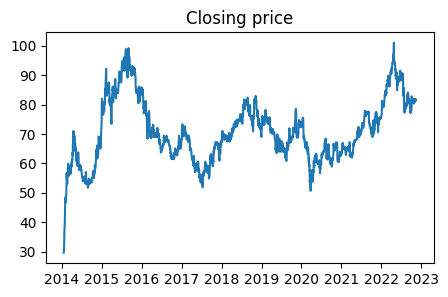

In [ ]:
plt.figure(figsize=(5,3))
plt.plot(df['Date'],df['Close'])
plt.title('Closing price')
plt.show()

In [ ]:
df['MA_10'] = df['Close'].rolling(10).mean()

Input feature & Targeted Variable

In [ ]:
x=df[['Open', 'High', 'Low', 'Volume']]
y=df['Close']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

Train Model

In [ ]:
model = LinearRegression()
model.fit(x_train, y_train)
print("\nModel Training Completed")


Model Training Completed


Prediction

In [ ]:
y_pred = model.predict(x_test)

Evaluation

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation")
print("-------------------------")
print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)



Model Evaluation
-------------------------
MAE  : 0.32123419607488546
MSE  : 0.18810214838425918
RMSE : 0.4337074456177334
R2 Score : 0.9982632455770415


Actual vs Predicted

In [ ]:
Comparison=pd.DataFrame({'Actual':y_test,'Predicted':y_pred})

print("\nActual vs Predicted")
print(Comparison.head(10))


Actual vs Predicted
      Actual  Predicted
1305   70.62  70.616813
260    88.76  88.966863
1517   63.26  63.777634
2097   90.71  90.975050
1281   73.91  73.884262
1006   69.42  69.464961
655    66.80  66.746710
929    60.00  59.120042
721    67.42  67.164305
350    88.37  88.612754


Visualization

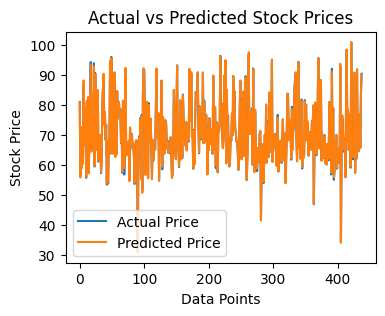

In [ ]:
plt.figure(figsize=(4,3))
plt.plot(y_test.values, label='Actual Price')
plt.plot(y_pred, label='Predicted Price')
plt.title('Actual vs Predicted Stock Prices')
plt.xlabel('Data Points')
plt.ylabel('Stock Price')
plt.legend()
plt.show()

Predicted New Data

In [ ]:
new_data = [[70, 72, 69, 500000]]

prediction = model.predict(new_data)

print("\nPredicted Closing Price:")
print(prediction[0])


Predicted Closing Price:
70.61476077617031


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
